# Preliminary Analysis: Market Odds Performance

Evaluate the predictive accuracy of pre-tipoff market odds from **Kalshi** and **Polymarket** for both **WNBA** and **NBA** moneyline markets.

Metrics: **log loss**, **Brier score**, **accuracy**

Filter: regular season + playoff games only (no preseason, All-Star, exhibition)

In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

REPO = Path('.').resolve().parent.parent  # repo root
print(f'Repo root: {REPO}')

Repo root: C:\Users\arius\Desktop\kalshi_wnba_bot


## 1. Load data

In [28]:
# ── Paths ────────────────────────────────────────────────────────────────────
WNBA_KALSHI   = REPO / 'data' / 'kalshi'
WNBA_POLY     = REPO / 'data' / 'polymarket'
NBA_KALSHI    = REPO / 'NBA' / 'data' / 'kalshi'
NBA_POLY      = REPO / 'NBA' / 'data' / 'polymarket'

# ── WNBA ─────────────────────────────────────────────────────────────────────
wk_games    = pd.read_csv(WNBA_KALSHI / 'wnba_2025_game_markets.csv')
wk_markets  = pd.read_csv(WNBA_KALSHI / 'kalshi_markets.csv')
wk_candles  = pd.read_csv(WNBA_KALSHI / 'kalshi_candles_1m.csv')
wk_settle   = pd.read_csv(WNBA_KALSHI / 'kalshi_settlements.csv')

wp_markets  = pd.read_csv(WNBA_POLY / 'polymarket_markets.csv', low_memory=False)
wp_prices   = pd.read_csv(WNBA_POLY / 'polymarket_prices_history.csv')
wp_settle   = pd.read_csv(WNBA_POLY / 'polymarket_settlements.csv', low_memory=False)
wp_tokens   = pd.read_csv(WNBA_POLY / 'polymarket_tokens.csv')
wp_ml       = wp_markets[wp_markets['sports_market_type'] == 'moneyline'].copy()

print(f'WNBA Kalshi:     {len(wk_games)} games, {len(wk_candles):,} candles')
print(f'WNBA Polymarket: {len(wp_ml)} moneyline markets, {len(wp_prices):,} price points')

# ── NBA ──────────────────────────────────────────────────────────────────────
nk_games    = pd.read_csv(NBA_KALSHI / 'nba_game_markets.csv')
nk_markets  = pd.read_csv(NBA_KALSHI / 'kalshi_markets.csv')
nk_settle   = pd.read_csv(NBA_KALSHI / 'kalshi_settlements.csv')
nk_candles  = pd.read_csv(NBA_KALSHI / 'kalshi_pretipoff_candles.csv') if (NBA_KALSHI / 'kalshi_pretipoff_candles.csv').exists() else pd.DataFrame()

np_markets  = pd.read_csv(NBA_POLY / 'polymarket_markets.csv', low_memory=False)
np_settle   = pd.read_csv(NBA_POLY / 'polymarket_settlements.csv', low_memory=False)
np_ml       = np_markets[np_markets['sports_market_type'] == 'moneyline'].copy()
np_prices   = pd.read_csv(NBA_POLY / 'polymarket_pretipoff_prices.csv') if (NBA_POLY / 'polymarket_pretipoff_prices.csv').exists() else pd.DataFrame()

print(f'NBA Kalshi:      {len(nk_games)} games, {len(nk_candles)} pre-tipoff candles')
print(f'NBA Polymarket:  {len(np_ml)} moneyline markets, {len(np_prices)} pre-tipoff prices')

WNBA Kalshi:     298 games, 497,104 candles
WNBA Polymarket: 283 moneyline markets, 1,417,330 price points
NBA Kalshi:      721 games, 710 pre-tipoff candles
NBA Polymarket:  1514 moneyline markets, 1510 pre-tipoff prices


## 2. Extract pre-tipoff odds

In [29]:
def kalshi_pretipoff(games_df, markets_df, candles_df, pre_fetched=False):
    """
    Get the last pre-tipoff bid/ask midpoint for each settled Kalshi game.
    
    Pre-tipoff cutoff: game_date at 23:00 UTC (6pm ET). Most games tip off
    at 7pm ET or later, so this is conservative.
    
    If pre_fetched=True, candles_df already contains one row per game with
    a 'mid_price' column (NBA path). The candle may be for either team's
    market, so we align to team_a using the markets table.
    """
    settled = games_df[games_df['status'] == 'finalized'].copy()
    game_info = settled[['event_ticker', 'game_date', 'team_a', 'winner']].copy()
    game_info['outcome'] = (game_info['team_a'] == game_info['winner']).astype(int)
    
    if candles_df.empty:
        return pd.DataFrame()
    
    # Map market_ticker -> which team the YES side represents
    mkt_team = dict(zip(markets_df['market_ticker'], markets_df['yes_sub_title']))
    
    if pre_fetched:
        # NBA path: candles_df has one row per game with mid_price
        result = candles_df.merge(
            game_info[['event_ticker', 'team_a', 'outcome']], on='event_ticker', how='inner'
        )
        # Align: if candle market is for team_b, flip the probability
        result['mkt_team'] = result['market_ticker'].map(mkt_team)
        result['implied_prob'] = np.where(
            result['mkt_team'] == result['team_a'],
            result['mid_price'],
            1 - result['mid_price']
        )
        return result[['event_ticker', 'game_date', 'implied_prob', 'outcome']]
    
    # ── WNBA path: full candle history -> find last candle before cutoff ─────
    # Identify team_a's market ticker per event
    mkts = markets_df[markets_df['event_ticker'].isin(set(settled['event_ticker']))].copy()
    mkts_a = mkts.merge(game_info[['event_ticker', 'team_a']], on='event_ticker')
    mkts_a = mkts_a[mkts_a['yes_sub_title'] == mkts_a['team_a']]
    team_a_tickers = set(mkts_a['market_ticker'])
    ticker_to_event = dict(zip(mkts_a['market_ticker'], mkts_a['event_ticker']))
    
    # Build per-event cutoff timestamps
    cutoff_map = {
        row['event_ticker']: pd.Timestamp(row['game_date'] + ' 23:00:00', tz='UTC')
        for _, row in game_info.iterrows()
    }
    
    # Filter candles to team_a markets only
    c = candles_df[candles_df['market_ticker'].isin(team_a_tickers)].copy()
    c['end_period_ts'] = pd.to_datetime(c['end_period_ts'], utc=True)
    c['event_ticker'] = c['market_ticker'].map(ticker_to_event)
    c['cutoff'] = c['event_ticker'].map(cutoff_map)
    
    # Keep only candles before the cutoff
    c = c[c['end_period_ts'] < c['cutoff']].copy()
    
    # Last candle per market -> use bid/ask midpoint as implied prob
    last = c.sort_values('end_period_ts').groupby('market_ticker').last().reset_index()
    last['implied_prob'] = (last['yes_bid_close'] + last['yes_ask_close']) / 2
    
    result = last[['market_ticker', 'implied_prob']].merge(
        mkts_a[['market_ticker', 'event_ticker']], on='market_ticker'
    ).merge(game_info[['event_ticker', 'game_date', 'outcome']], on='event_ticker')
    
    return result[['event_ticker', 'game_date', 'implied_prob', 'outcome']]


def polymarket_pretipoff(ml_markets_df, prices_df, settle_df, tokens_df=None, pre_fetched=False):
    """
    Get the last pre-tipoff price for each settled Polymarket moneyline market.
    
    Pre-tipoff cutoff: game_start_ts (Polymarket provides this directly).
    Uses outcome_index=0 / token_index=0 (team_a) as reference.
    
    If pre_fetched=True, prices_df already has one row per market with 'price'.
    Otherwise, prices_df is the full price history and we select last before tipoff.
    """
    resolved_cids = set(settle_df[settle_df['resolved_flag'] == True]['condition_id'])
    ml = ml_markets_df[ml_markets_df['condition_id'].isin(resolved_cids)].copy()
    ml['team_a'] = ml['outcomes'].str.split('|').str[0]
    
    settle_map = dict(zip(settle_df['condition_id'], settle_df['winning_outcome']))
    ml['winner'] = ml['condition_id'].map(settle_map)
    ml['outcome'] = (ml['team_a'] == ml['winner']).astype(int)
    
    if prices_df.empty:
        return pd.DataFrame()
    
    if pre_fetched:
        # NBA path: prices_df has one row per market with 'price'
        result = prices_df.merge(
            ml[['condition_id', 'outcome']], on='condition_id', how='inner'
        )
        result = result.rename(columns={'price': 'implied_prob', 'game_start_ts': 'game_date'})
        return result[['condition_id', 'game_date', 'implied_prob', 'outcome']]
    
    # ── WNBA path: full price history -> find last price before game_start_ts
    ml['game_start_ts'] = pd.to_datetime(ml['game_start_ts'], utc=True)
    ml = ml.dropna(subset=['game_start_ts'])
    
    # Get team_a tokens (token_index 0)
    t0 = tokens_df[tokens_df['token_index'] == 0][['condition_id', 'token_id']].copy()
    ml_tokens = ml.merge(t0, on='condition_id', how='inner')
    
    cutoff_map = dict(zip(ml_tokens['token_id'], ml_tokens['game_start_ts']))
    
    p = prices_df.copy()
    p['ts'] = pd.to_datetime(p['ts'], utc=True)
    p = p[p['token_id'].isin(set(ml_tokens['token_id']))].copy()
    p['cutoff'] = p['token_id'].map(cutoff_map)
    
    # Keep only pre-tipoff prices
    p = p[p['ts'] < p['cutoff']].copy()
    
    # Last price per token before tipoff
    last = p.sort_values('ts').groupby('token_id').last().reset_index()
    
    result = last[['token_id', 'price']].merge(
        ml_tokens[['token_id', 'condition_id', 'game_start_ts', 'outcome']],
        on='token_id'
    )
    result = result.rename(columns={'price': 'implied_prob', 'game_start_ts': 'game_date'})
    return result[['condition_id', 'game_date', 'implied_prob', 'outcome']]


print('Functions defined.')

Functions defined.


In [30]:
# ── Extract pre-tipoff odds: last candle/price before tipoff ─────────────────

print('=== WNBA Kalshi ===')
wk_result = kalshi_pretipoff(wk_games, wk_markets, wk_candles, pre_fetched=False)
print(f'  Games with pre-tipoff price: {len(wk_result)}')

print('\n=== WNBA Polymarket ===')
wp_result = polymarket_pretipoff(wp_ml, wp_prices, wp_settle, tokens_df=wp_tokens, pre_fetched=False)
print(f'  Games with pre-tipoff price: {len(wp_result)}')

print('\n=== NBA Kalshi ===')
nk_result = kalshi_pretipoff(nk_games, nk_markets, nk_candles, pre_fetched=True)
print(f'  Games with pre-tipoff price: {len(nk_result)}')

print('\n=== NBA Polymarket ===')
np_result = polymarket_pretipoff(np_ml, np_prices, np_settle, pre_fetched=True)
print(f'  Games with pre-tipoff price: {len(np_result)}')

=== WNBA Kalshi ===
  Games with pre-tipoff price: 298

=== WNBA Polymarket ===
  Games with pre-tipoff price: 283

=== NBA Kalshi ===
  Games with pre-tipoff price: 692

=== NBA Polymarket ===
  Games with pre-tipoff price: 1452


## 3. Evaluate

In [31]:
def evaluate(df, label):
    """Compute log loss, Brier score, and accuracy for a pre-tipoff odds DataFrame."""
    if df.empty:
        return {'source': label, 'n_games': 0, 'log_loss': np.nan,
                'brier': np.nan, 'accuracy': np.nan}
    
    y = df['outcome'].values
    p = df['implied_prob'].values
    
    # Clamp probabilities to avoid log(0)
    eps = 1e-4
    p = np.clip(p, eps, 1 - eps)
    
    ll = log_loss(y, p)
    bs = brier_score_loss(y, p)
    # Predicted class: p > 0.5 => team_a wins
    acc = accuracy_score(y, (p > 0.5).astype(int))
    
    return {'source': label, 'n_games': len(df), 'log_loss': round(ll, 4),
            'brier': round(bs, 4), 'accuracy': round(acc, 4)}


rows = [
    evaluate(wk_result, 'WNBA Kalshi'),
    evaluate(wp_result, 'WNBA Polymarket'),
    evaluate(nk_result, 'NBA Kalshi'),
    evaluate(np_result, 'NBA Polymarket'),
]

summary = pd.DataFrame(rows).set_index('source')
print(summary.to_string())
summary

                 n_games  log_loss   brier  accuracy
source                                              
WNBA Kalshi          298    0.6160  0.2151    0.6242
WNBA Polymarket      283    0.6240  0.2178    0.6643
NBA Kalshi           692    0.5689  0.1934    0.6994
NBA Polymarket      1452    0.5905  0.2038    0.6653


,n_games,log_loss,brier,accuracy
source,,,,
WNBA Kalshi,298,0.6160,0.2151,0.6242
WNBA Polymarket,283,0.6240,0.2178,0.6643
NBA Kalshi,692,0.5689,0.1934,0.6994
NBA Polymarket,1452,0.5905,0.2038,0.6653


## 4. Calibration curves

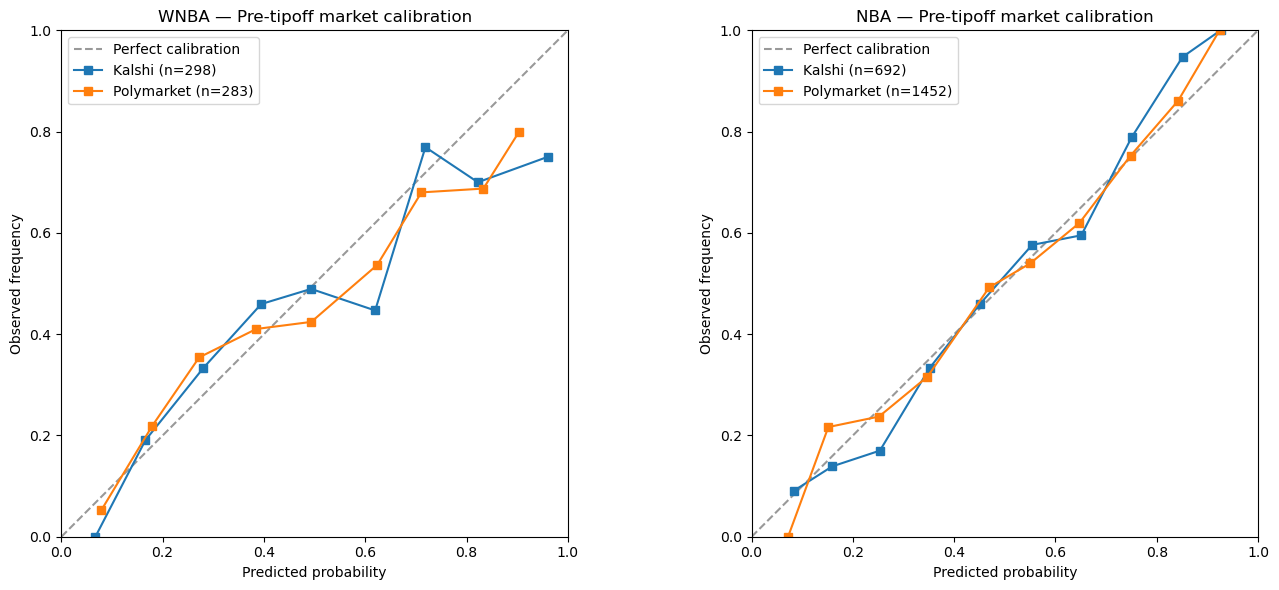

In [32]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [
    ('WNBA', [('Kalshi', wk_result), ('Polymarket', wp_result)]),
    ('NBA',  [('Kalshi', nk_result), ('Polymarket', np_result)]),
]

for ax, (sport, sources) in zip(axes, datasets):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    
    for label, df in sources:
        if df.empty:
            continue
        p = np.clip(df['implied_prob'].values, 1e-4, 1 - 1e-4)
        y = df['outcome'].values
        
        n_bins = min(10, max(3, len(df) // 30))
        try:
            frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy='uniform')
            ax.plot(mean_pred, frac_pos, 's-', label=f'{label} (n={len(df)})', markersize=6)
        except Exception:
            pass
    
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_title(f'{sport} — Pre-tipoff market calibration')
    ax.legend(loc='upper left')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 5. Probability distributions

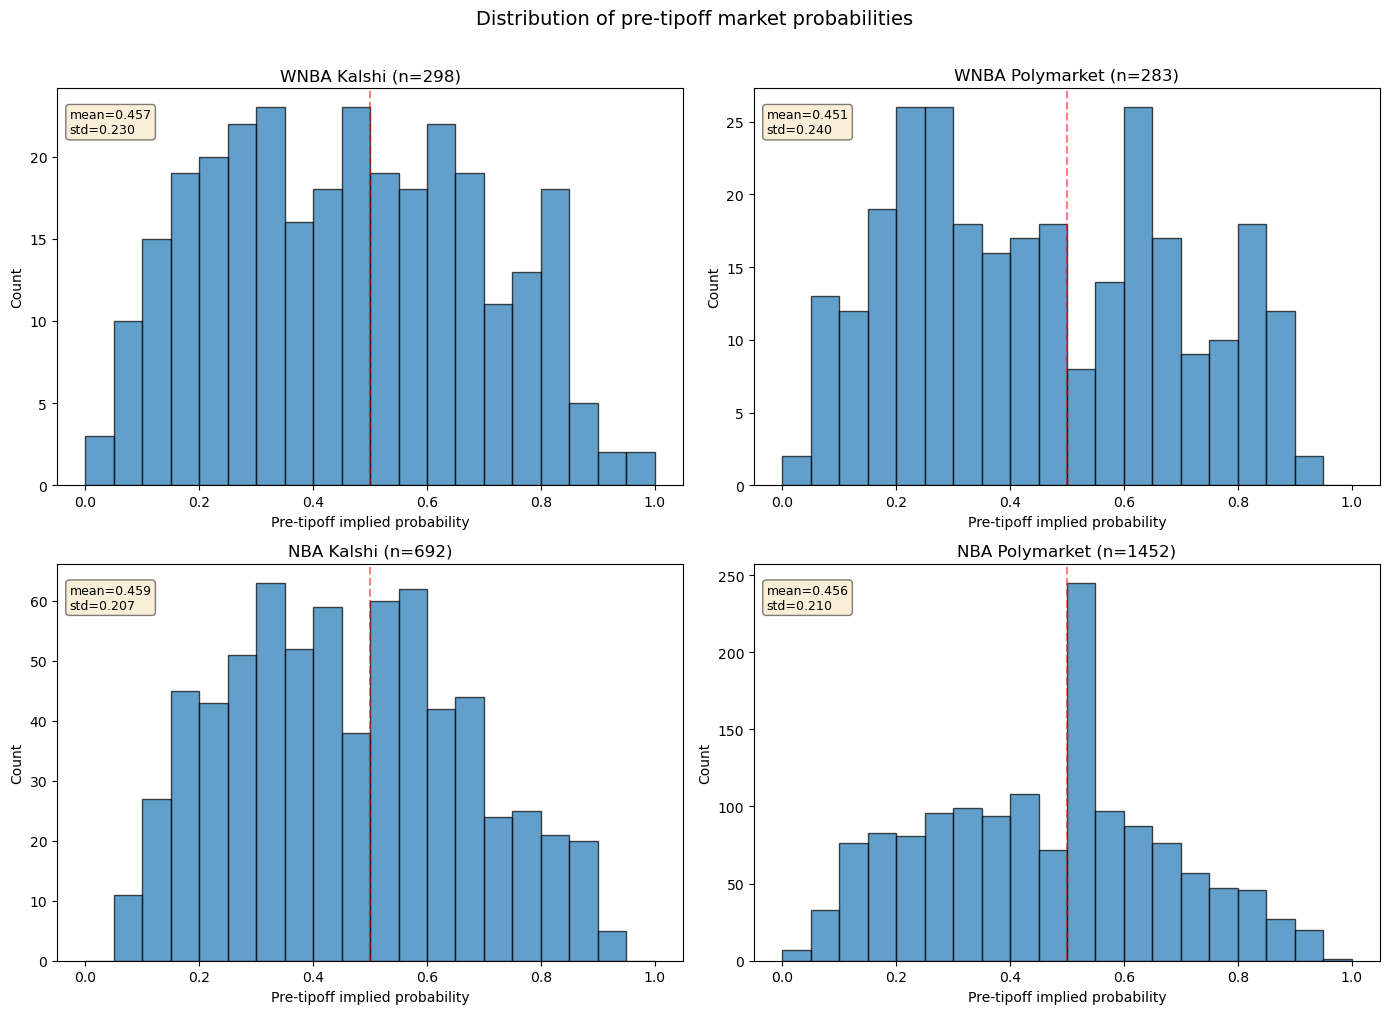

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_results = [
    ('WNBA Kalshi', wk_result),
    ('WNBA Polymarket', wp_result),
    ('NBA Kalshi', nk_result),
    ('NBA Polymarket', np_result),
]

for ax, (label, df) in zip(axes.flat, all_results):
    if df.empty:
        ax.set_title(f'{label} — no data')
        continue
    
    p = df['implied_prob'].values
    ax.hist(p, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{label} (n={len(df)})')
    ax.set_xlabel('Pre-tipoff implied probability')
    ax.set_ylabel('Count')
    
    # Stats
    ax.text(0.02, 0.95, f'mean={p.mean():.3f}\nstd={p.std():.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribution of pre-tipoff market probabilities', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()